# Task I: Quantum Computing

## Part 1: 5-Qubit Circuit (Cirq)

**Requirements:**
- (a) 5 qubits
- (b) Hadamard on every qubit
- (c) CNOT on (0,1), (1,2), (2,3), (3,4)
- (d) SWAP(0, 4)
- (e) Rotate X with π/2 on qubit 2
- (f) Plot the circuit

In [1]:
import cirq
import numpy as np
import matplotlib.pyplot as plt

# (a) 5 qubits
qubits = cirq.LineQubit.range(5)
circuit = cirq.Circuit()

# (b) Hadamard on every qubit
circuit.append(cirq.H.on_each(*qubits))

# (c) CNOT on (0,1), (1,2), (2,3), (3,4)
circuit.append([
    cirq.CNOT(qubits[0], qubits[1]),
    cirq.CNOT(qubits[1], qubits[2]),
    cirq.CNOT(qubits[2], qubits[3]),
    cirq.CNOT(qubits[3], qubits[4]),
])

# (d) SWAP(0, 4)
circuit.append(cirq.SWAP(qubits[0], qubits[4]))

# (e) Rotate X with pi/2 on qubit 2
circuit.append(cirq.rx(np.pi / 2)(qubits[2]))

# (f) Measure all qubits
circuit.append(cirq.measure(*qubits, key='result'))

print(circuit)

0: ───H───@──────────────────────×───M('result')───
          │                      │   │
1: ───H───X───@──────────────────┼───M─────────────
              │                  │   │
2: ───H───────X───@───Rx(0.5π)───┼───M─────────────
                  │              │   │
3: ───H───────────X───@──────────┼───M─────────────
                      │          │   │
4: ───H───────────────X──────────×───M─────────────


### Plot the Circuit

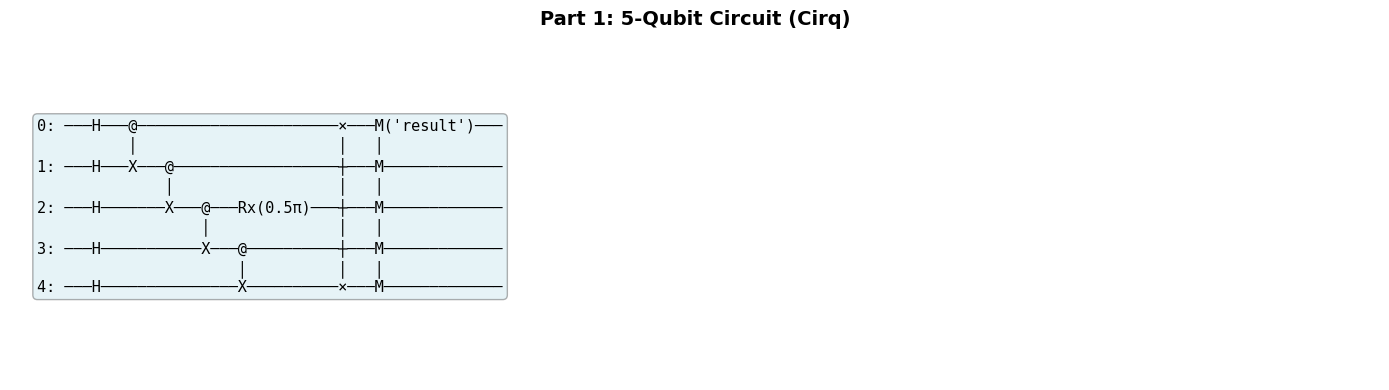

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
cirq_diagram = circuit.to_text_diagram(transpose=False)
ax.text(0.02, 0.5, cirq_diagram, transform=ax.transAxes,
        fontsize=11, verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.set_axis_off()
ax.set_title("Part 1: 5-Qubit Circuit (Cirq)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Simulate the Circuit

In [3]:
# Simulate (exclude measurement gate for state vector)
simulator = cirq.Simulator()
result = simulator.simulate(circuit[:-1])
print("Final state vector (first 8 amplitudes):")
print(np.round(result.final_state_vector[:8], 4))

Final state vector (first 8 amplitudes):
[0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j]


---

## Part 2: SWAP Test Circuit (PennyLane)

**Requirements:**
- Hadamard gate on the first qubit
- Rotate the second qubit by π/3 around X
- Hadamard gate on the third and fourth qubit
- SWAP test between |q1 q2⟩ and |q3 q4⟩

**Circuit design:**
- Wire 0 = ancilla qubit for the SWAP test
- Wires 1,2 = first state |ψ⟩ = H|0⟩ ⊗ Rx(π/3)|0⟩
- Wires 3,4 = second state |φ⟩ = H|0⟩ ⊗ H|0⟩
- The SWAP test uses: H(ancilla) → CSWAP(ancilla, q1, q3) → CSWAP(ancilla, q2, q4) → H(ancilla)
- P(|0⟩) on ancilla gives (1 + |⟨ψ|φ⟩|²) / 2

In [4]:
import pennylane as qml

dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def swap_test_circuit():
    # Prepare |q1>: Hadamard on first qubit (wire 1)
    qml.Hadamard(wires=1)
    
    # Prepare |q2>: Rotate second qubit by pi/3 around X (wire 2)
    qml.RX(np.pi / 3, wires=2)
    
    # Prepare |q3>: Hadamard on third qubit (wire 3)
    qml.Hadamard(wires=3)
    
    # Prepare |q4>: Hadamard on fourth qubit (wire 4)
    qml.Hadamard(wires=4)
    
    # --- SWAP Test ---
    # Ancilla = wire 0
    qml.Hadamard(wires=0)
    
    # Controlled-SWAP between corresponding qubits
    qml.CSWAP(wires=[0, 1, 3])
    qml.CSWAP(wires=[0, 2, 4])
    
    # Final Hadamard on ancilla
    qml.Hadamard(wires=0)
    
    # P(|0>) = (1 + |<psi|phi>|^2) / 2
    return qml.probs(wires=0)

# Draw the circuit
print(qml.draw(swap_test_circuit)())

0: ──H────────╭●────╭●─────H─┤  Probs
1: ──H────────├SWAP─│────────┤       
2: ──RX(1.05)─│─────├SWAP────┤       
3: ──H────────╰SWAP─│────────┤       
4: ──H──────────────╰SWAP────┤       


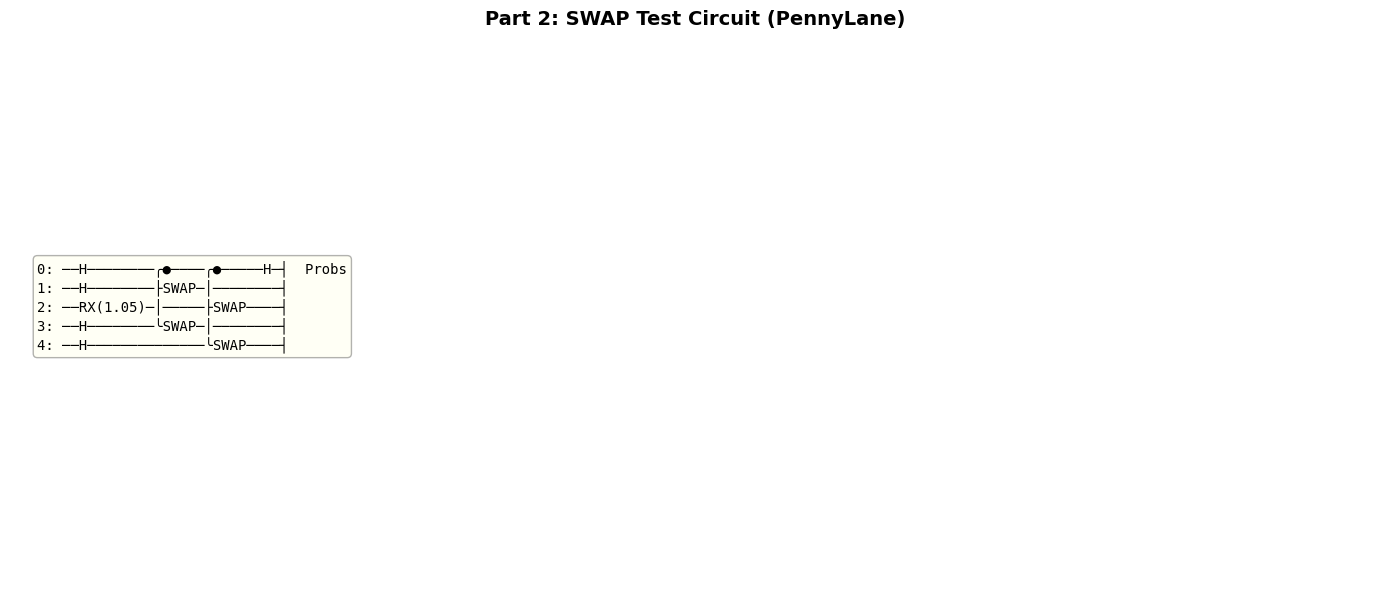

In [5]:
# Plot the SWAP test circuit
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
circuit_str = qml.draw(swap_test_circuit)()
ax.text(0.02, 0.5, circuit_str, transform=ax.transAxes,
        fontsize=10, verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))
ax.set_axis_off()
ax.set_title("Part 2: SWAP Test Circuit (PennyLane)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Run SWAP Test & Interpret Results

In [6]:
# Run the SWAP test
probs = swap_test_circuit()

print(f"Ancilla measurement probabilities:")
print(f"  P(|0>) = {probs[0]:.6f}")
print(f"  P(|1>) = {probs[1]:.6f}")

# Fidelity: P(|0>) = (1 + |<psi|phi>|^2) / 2
overlap_sq = 2 * float(probs[0]) - 1
print(f"\n|<psi|phi>|^2 = {overlap_sq:.6f}")
print(f"|<psi|phi>|   = {np.sqrt(max(overlap_sq, 0)):.6f}")

print("\nInterpretation:")
print("  |psi> = H|0> x Rx(pi/3)|0> = |+> x (cos(pi/6)|0> + i*sin(pi/6)|1>)")
print("  |phi> = H|0> x H|0>        = |+> x |+>")
print(f"  The overlap^2 = {overlap_sq:.4f} shows partial similarity between the two 2-qubit states.")

Ancilla measurement probabilities:
  P(|0>) = 0.750000
  P(|1>) = 0.250000

|<psi|phi>|^2 = 0.500000
|<psi|phi>|   = 0.707107

Interpretation:
  |psi> = H|0> x Rx(pi/3)|0> = |+> x (cos(pi/6)|0> + i*sin(pi/6)|1>)
  |phi> = H|0> x H|0>        = |+> x |+>
  The overlap^2 = 0.5000 shows partial similarity between the two 2-qubit states.
